# 03 - Entraînement du modèle

On recharge les données brutes et on applique la normalisation sauvegardée dans `normalization.json` (calculée dans `02_preprocessing.ipynb`), sans la recalculer : sinon les valeurs seraient légèrement différentes de celles utilisées plus tard dans la simulation.

Modèle choisi : un petit CNN 1D. Il capte les motifs répétés dans le temps, a peu de paramètres, et dispose d'un chemin de quantification int8 simple et mature dans TensorFlow Lite. Un LSTM est techniquement supporté par TensorFlow Lite Micro mais avec des contraintes fortes (variante standard uniquement, format de quantification particulier pour l'état interne).

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/raw/UCI HAR Dataset")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1790198038.562589   26060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790198038.565300   26060 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790198038.845720   26060 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790198040.191345   26060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790198040.193899   26060 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Recharger les données et la normalisation figée à l'étape précédente

In [2]:
with open(MODELS_DIR / "normalization.json") as f:
    normalization = json.load(f)

CHANNELS = normalization["channels"]
mean = np.array(normalization["mean"])
std = np.array(normalization["std"])
validation_subjects = normalization["validation_subjects"]

def load_ids(path):
    return pd.read_csv(path, header=None, names=["value"]).squeeze("columns")

def load_signal(split, signal_name):
    path = DATA_DIR / split / "Inertial Signals" / f"{signal_name}_{split}.txt"
    return np.loadtxt(path)

def load_windows(split):
    signals = [load_signal(split, name) for name in CHANNELS]
    return np.stack(signals, axis=-1)

def normalize(X):
    return (X - mean) / std

X_train_full = load_windows("train")
X_test = normalize(load_windows("test"))
subject_train_full = load_ids(DATA_DIR / "train" / "subject_train.txt")
y_train_full = (load_ids(DATA_DIR / "train" / "y_train.txt") - 1).to_numpy()
y_test = (load_ids(DATA_DIR / "test" / "y_test.txt") - 1).to_numpy()

val_mask = subject_train_full.isin(validation_subjects).to_numpy()
fit_mask = ~val_mask

X_fit = normalize(X_train_full[fit_mask])
y_fit = y_train_full[fit_mask]
X_val = normalize(X_train_full[val_mask])
y_val = y_train_full[val_mask]

print("X_fit:", X_fit.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_fit: (5551, 128, 9) X_val: (1801, 128, 9) X_test: (2947, 128, 9)


## Architecture du CNN 1D

- Deux couches `Conv1D` extraient des motifs locaux, une couche de pooling réduit la longueur de séquence.
- `GlobalAveragePooling1D` plutôt qu'un `Flatten` : résume chaque canal en une valeur, donc beaucoup moins de paramètres dans la couche dense suivante.
- `Dropout` avant la dernière couche pour limiter le sur-apprentissage, vu la taille modeste du jeu d'entraînement (5551 fenêtres).

In [3]:
n_classes = len(np.unique(y_fit))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, len(CHANNELS))),
    tf.keras.layers.Conv1D(16, kernel_size=5, padding="same", activation="relu"),
    tf.keras.layers.Conv1D(32, kernel_size=5, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(n_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

E0000 00:00:1790198043.759582   26060 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,686 (30.02 KB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 0 (0.00 B)

## Entraînement

`EarlyStopping` sur la perte de validation : si elle ne s'améliore plus pendant 15 époques, on arrête et on garde les meilleurs poids rencontrés. Ça évite de fixer arbitrairement un nombre d'époques et limite le sur-apprentissage.

In [4]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = model.fit(
    X_fit, y_fit,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=2,
)

Epoch 1/100


87/87 - 1s - 15ms/step - accuracy: 0.6130 - loss: 1.1074 - val_accuracy: 0.9589 - val_loss: 0.3220


Epoch 2/100


87/87 - 0s - 3ms/step - accuracy: 0.8768 - loss: 0.3406 - val_accuracy: 0.9706 - val_loss: 0.1350


Epoch 3/100


...

87/87 - 0s - 3ms/step - accuracy: 0.9568 - loss: 0.0906 - val_accuracy: 0.9572 - val_loss: 0.1603


Epoch 26/100


87/87 - 0s - 3ms/step - accuracy: 0.9578 - loss: 0.0867 - val_accuracy: 0.9567 - val_loss: 0.1403


Epoch 27/100


87/87 - 0s - 3ms/step - accuracy: 0.9607 - loss: 0.0890 - val_accuracy: 0.9528 - val_loss: 0.1488


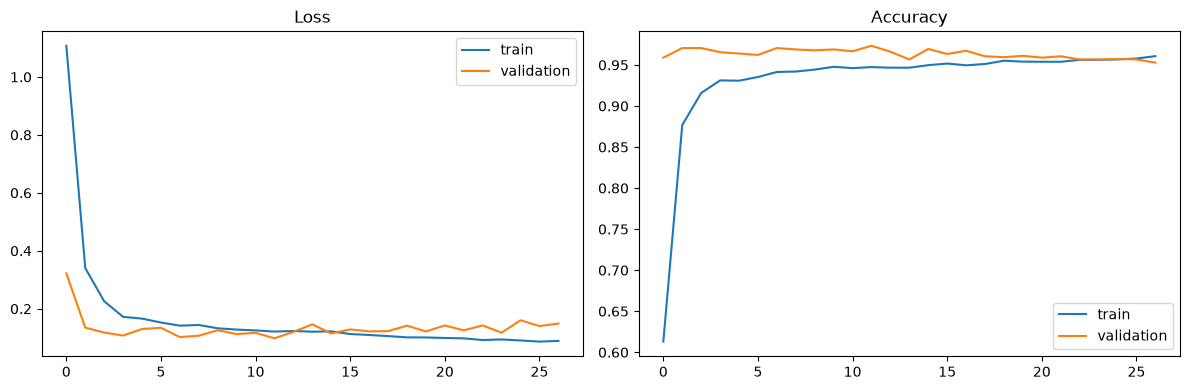

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png")
plt.show()

## Sauvegarde du modèle entraîné

Format Keras natif (`.keras`) pour l'instant. La conversion en TensorFlow Lite se fait dans le notebook suivant, une fois le modèle évalué et figé.

In [6]:
model.save(MODELS_DIR / "model.keras")

val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"validation accuracy: {val_accuracy:.3f}")
print(f"test accuracy (indicative only, real evaluation in the next notebook): {test_accuracy:.3f}")

validation accuracy: 0.973
test accuracy (indicative only, real evaluation in the next notebook): 0.893


## Observations

- **Taille :** 7686 paramètres (30 Ko en float32), bien sous la barre des quelques dizaines de milliers visée pour l'embarqué.
- **Arrêt anticipé :** meilleure époque à 12 (val_accuracy 0.973), arrêt à l'époque 27, poids de l'époque 12 restaurés automatiquement.
- **Courbes :** train et validation restent proches, pas de décrochage brutal, pas de sur-apprentissage évident.
- **Écart validation (0.973) vs test (0.893) :** normal, pas un bug. La validation utilise 5 sujets qu'on a choisis nous-même, le test est l'ensemble officiel avec 9 autres personnes. Le vrai chiffre à retenir est celui du test, analysé en détail dans le notebook suivant.